In [1]:
##Imports and configuration

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
## Load dataset

PROJECT_ROOT = Path.cwd().parent
DATA_PATH=PROJECT_ROOT/"data"/"raw"/"credit_score_data.csv"
df=pd.read_csv(DATA_PATH)
print(f"Dateset path:{DATA_PATH}")
print(f"Data shape: {df.shape}")

Dateset path:d:\Work_Learning_folder\MLOps_project\loan-default-mlops\data\raw\credit_score_data.csv
Data shape: (1000, 87)


In [3]:
## Basic dataset information

print(f"Shape:")
print(df.shape)

print(f"Data types:")
print(f"{df.dtypes.value_counts()}")

Shape:
(1000, 87)
Data types:
float64    51
int64      34
str         2
Name: count, dtype: int64


In [4]:
## Column-level information

data_info=pd.DataFrame({
    "column":df.columns,
    "dtype":df.dtypes,
    "missing_count":df.isnull().sum(),
    "unique_count":df.nunique().values
})

data_info.sort_values(by=["unique_count"],ascending=[False])

,column,dtype,missing_count,unique_count
CUST_ID,CUST_ID,str,0,1000
T_EXPENDITURE_12,T_EXPENDITURE_12,int64,0,999
T_EXPENDITURE_6,T_EXPENDITURE_6,int64,0,993
SAVINGS,SAVINGS,int64,0,992
T_GROCERIES_12,T_GROCERIES_12,int64,0,986
T_GROCERIES_6,T_GROCERIES_6,int64,0,968
INCOME,INCOME,int64,0,951
DEBT,DEBT,int64,0,943
T_ENTERTAINMENT_12,T_ENTERTAINMENT_12,int64,0,934
T_ENTERTAINMENT_6,T_ENTERTAINMENT_6,int64,0,932


In [5]:
#Missing-value analysis

missing_summary = (
    df.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] /
    len(df) * 100
)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values("missing_pct", ascending=False)
)

missing_summary

,missing_count,missing_pct


In [6]:
## Duplicate analysis
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [7]:
## Target analysis
target="DEFAULT"

target_counts=df[target].value_counts().sort_index()
target_pcts=df[target].value_counts(normalize=True).sort_index()*100

target_summary=pd.DataFrame({
    'count':target_counts,
    'percentage':target_pcts

})

target_summary

,count,percentage
DEFAULT,,
0,716,71.6000
1,284,28.4000


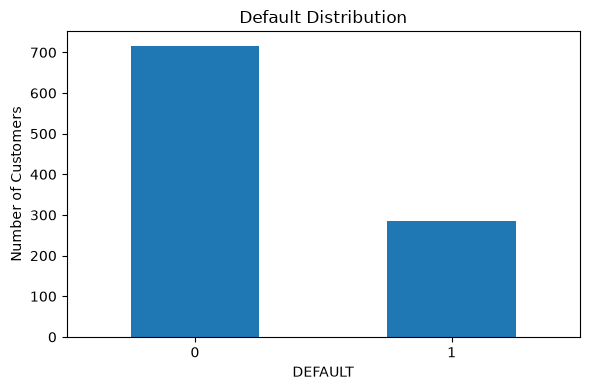

In [8]:
## Target visualization

plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("DEFAULT")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
## Numerical feature analysis

categorical_features=df.select_dtypes(include=["object","category"]).columns.tolist()


numerical_features =df.select_dtypes(include=["number"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Categorical features:
['CUST_ID', 'CAT_GAMBLING']

Number of numerical features: 85
Number of categorical features: 2


In [10]:
## Numerical summary
numerical_summary = df[numerical_features].describe().T

numerical_summary["missing_pct"] = (
    df[numerical_features].isnull().mean() * 100
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max,missing_pct
INCOME,1000.0000,121610.0190,113716.6996,0.0000,30450.2500,85090.0000,181217.5000,662094.0000,0.0000
SAVINGS,1000.0000,413189.5970,442916.0371,0.0000,59719.7500,273850.5000,622260.0000,2911863.0000,0.0000
DEBT,1000.0000,790718.0450,981790.3914,0.0000,53966.7500,395095.5000,1193230.0000,5968620.0000,0.0000
R_SAVINGS_INCOME,1000.0000,4.0635,3.9681,0.0000,1.0000,2.5454,6.3071,16.1112,0.0000
R_DEBT_INCOME,1000.0000,6.0684,5.8479,0.0000,1.4545,4.9116,8.5875,37.0006,0.0000
R_DEBT_SAVINGS,1000.0000,5.8673,16.7884,0.0000,0.2062,2.0000,4.5096,292.8421,0.0000
T_CLOTHING_12,1000.0000,6822.4010,7486.2259,0.0000,1084.5000,4494.0000,10148.5000,43255.0000,0.0000
T_CLOTHING_6,1000.0000,3466.3200,5118.9430,0.0000,319.5000,1304.0000,4555.5000,39918.0000,0.0000
R_CLOTHING,1000.0000,0.4548,0.2360,0.0000,0.2640,0.4688,0.6263,1.0583,0.0000
R_CLOTHING_INCOME,1000.0000,0.0556,0.0376,0.0034,0.0297,0.0468,0.0694,0.2517,0.0000


In [11]:
## Cardinality analysis
cardinality = pd.DataFrame({
    "feature": df.columns,
    "unique_values": df.nunique(),
    "unique_pct": df.nunique() / len(df) * 100
})

cardinality.sort_values(
    "unique_values",
    ascending=False
).head(20)

,feature,unique_values,unique_pct
CUST_ID,CUST_ID,1000,100.0000
T_EXPENDITURE_12,T_EXPENDITURE_12,999,99.9000
T_EXPENDITURE_6,T_EXPENDITURE_6,993,99.3000
SAVINGS,SAVINGS,992,99.2000
T_GROCERIES_12,T_GROCERIES_12,986,98.6000
T_GROCERIES_6,T_GROCERIES_6,968,96.8000
INCOME,INCOME,951,95.1000
DEBT,DEBT,943,94.3000
T_ENTERTAINMENT_12,T_ENTERTAINMENT_12,934,93.4000
T_ENTERTAINMENT_6,T_ENTERTAINMENT_6,932,93.2000


In [12]:
## Categorical analysis

# Categorical distributions
for column in categorical_features:

    print(f"\n{'=' * 60}")
    print(f"Feature: {column}")
    print(f"{'=' * 60}")

    print(df[column].value_counts(dropna=False))


Feature: CUST_ID
CUST_ID
C02COQEVYU    1
C02OZKC0ZF    1
C03FHP2D0A    1
C03PVPPHOY    1
C04J69MUX0    1
             ..
CZQHJC9HDH    1
CZRA4MLB0P    1
CZSOD1KVFX    1
CZWC76UAUT    1
CZZV5B3SAL    1
Name: count, Length: 1000, dtype: int64

Feature: CAT_GAMBLING
CAT_GAMBLING
No      620
High    264
Low     116
Name: count, dtype: int64


In [13]:
## Default relationship analysis

#Default rate by categorical feature

for column in categorical_features:

    if column == "CUST_ID":
        continue

    summary = (
        df.groupby(column)[target]
        .agg(
            customers="count",
            defaults="sum",
            default_rate="mean"
        )
        .sort_values("default_rate", ascending=False)
    )

    summary["default_rate"] *= 100

    print(f"\n{column}")
    display(summary)


CAT_GAMBLING


,customers,defaults,default_rate
CAT_GAMBLING,,,
High,264,85,32.1970
Low,116,33,28.4483
No,620,166,26.7742


In [14]:
numeric_default_analysis = (
    df.groupby(target)[numerical_features]
    .mean()
    .T
)
numeric_default_analysis.columns=["Non_Default",
    "Default"
]

numeric_default_analysis["difference"] = (
    numeric_default_analysis["Default"] -
    numeric_default_analysis["Non_Default"]
)

numeric_default_analysis.sort_values(
    "difference",
    ascending=False
)

numeric_default_analysis


,Non_Default,Default,difference
INCOME,120990.2039,123172.6514,2182.4475
SAVINGS,415296.4260,407878.0141,-7418.4119
DEBT,719916.6355,969217.3732,249300.7378
R_SAVINGS_INCOME,4.2146,3.6826,-0.5320
R_DEBT_INCOME,4.9897,8.7880,3.7983
R_DEBT_SAVINGS,4.4197,9.5166,5.0968
T_CLOTHING_12,6771.8645,6949.8099,177.9453
T_CLOTHING_6,3379.2598,3685.8099,306.5501
R_CLOTHING,0.4530,0.4596,0.0066
R_CLOTHING_INCOME,0.0557,0.0553,-0.0003


In [15]:
##Correlation analysis
correlation_with_target = (
    df[numerical_features]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

correlation_with_target.head(20)

CREDIT_SCORE           -0.3331
R_DEBT_INCOME           0.2930
R_EXPENDITURE_DEBT     -0.1393
R_DEBT_SAVINGS          0.1370
R_ENTERTAINMENT_DEBT   -0.1342
R_TAX_DEBT             -0.1337
R_UTILITIES_DEBT       -0.1306
R_GROCERIES_DEBT       -0.1240
R_HEALTH_DEBT          -0.1230
CAT_CREDIT_CARD         0.1200
R_GROCERIES_SAVINGS     0.1176
DEBT                    0.1146
R_CLOTHING_DEBT        -0.1134
R_TRAVEL_DEBT          -0.1132
R_EDUCATION_SAVINGS     0.0999
R_UTILITIES_SAVINGS     0.0986
R_EDUCATION_INCOME      0.0965
R_HEALTH_SAVINGS        0.0874
R_HOUSING_DEBT         -0.0865
R_GROCERIES_INCOME      0.0853
Name: DEFAULT, dtype: float64

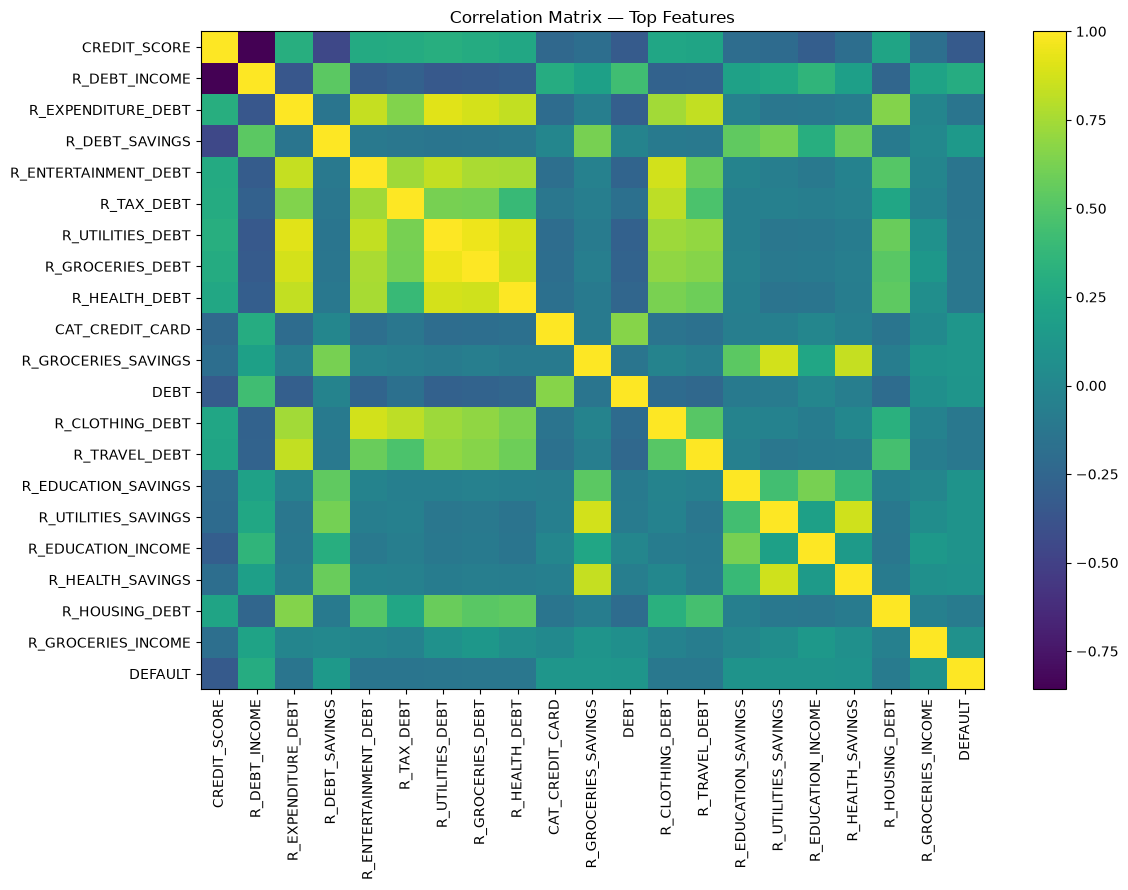

In [16]:
## Correlation matrix

top_corr_features = (
    correlation_with_target
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

corr_matrix = df[
    top_corr_features + [target]
].corr()

plt.figure(figsize=(12, 9))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Correlation Matrix — Top Features")

plt.tight_layout()
plt.show()

In [17]:
## Outlier analysis

outlier_summary = []

for column in numerical_features:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "feature": column,
        "outlier_count": outliers,
        "outlier_pct": outliers / len(df) * 100
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values("outlier_pct", ascending=False)
)

outlier_summary.head(20)

,feature,outlier_count,outlier_pct
50,R_HOUSING,479,47.9000
56,R_TAX,422,42.2000
79,CAT_CREDIT_CARD,236,23.6000
34,R_GAMBLING_SAVINGS,234,23.4000
31,T_GAMBLING_6,184,18.4000
30,T_GAMBLING_12,184,18.4000
80,CAT_MORTGAGE,173,17.3000
47,R_HEALTH_DEBT,165,16.5000
53,R_HOUSING_DEBT,160,16.0000
33,R_GAMBLING_INCOME,160,16.0000


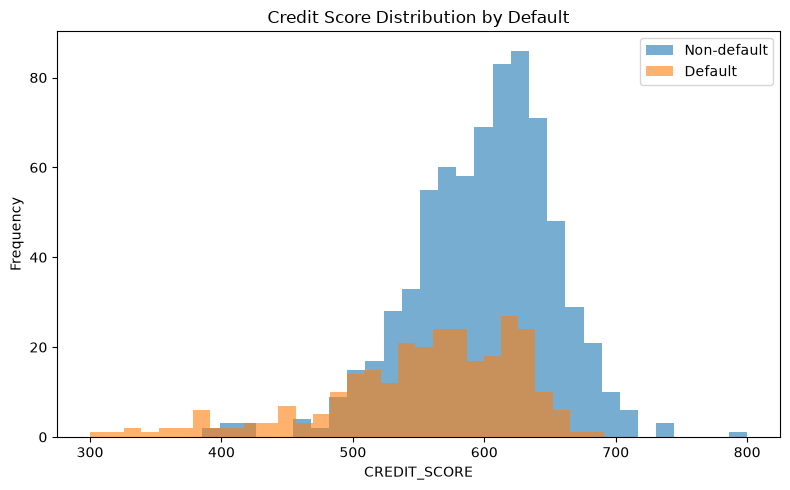

In [18]:
## CREDIT_SCORE analysis

df.groupby(target)["CREDIT_SCORE"].agg(
    ["count", "mean", "median", "min", "max"]
)

plt.figure(figsize=(8, 5))

df[df[target] == 0]["CREDIT_SCORE"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Non-default"
)

df[df[target] == 1]["CREDIT_SCORE"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Default"
)

plt.title("Credit Score Distribution by Default")
plt.xlabel("CREDIT_SCORE")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
##Save EDA output

eda_report = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_customer_ids": int(df["CUST_ID"].duplicated().sum()),
    "missing_cells": int(df.isnull().sum().sum()),
    "default_count": int(df[target].sum()),
    "non_default_count": int((df[target] == 0).sum())
}

eda_report

{'rows': 1000,
 'columns': 87,
 'duplicate_rows': 0,
 'duplicate_customer_ids': 0,
 'missing_cells': 0,
 'default_count': 284,
 'non_default_count': 716}

In [20]:
##Feature correlation with target
TARGET = "DEFAULT"
ID_COLUMN = "CUST_ID"

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features = [
    col
    for col in numerical_columns
    if col != TARGET
]

target_correlations = (
    df[numerical_features + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

target_correlations.head(20)

CREDIT_SCORE           -0.3331
R_DEBT_INCOME           0.2930
R_EXPENDITURE_DEBT     -0.1393
R_DEBT_SAVINGS          0.1370
R_ENTERTAINMENT_DEBT   -0.1342
R_TAX_DEBT             -0.1337
R_UTILITIES_DEBT       -0.1306
R_GROCERIES_DEBT       -0.1240
R_HEALTH_DEBT          -0.1230
CAT_CREDIT_CARD         0.1200
R_GROCERIES_SAVINGS     0.1176
DEBT                    0.1146
R_CLOTHING_DEBT        -0.1134
R_TRAVEL_DEBT          -0.1132
R_EDUCATION_SAVINGS     0.0999
R_UTILITIES_SAVINGS     0.0986
R_EDUCATION_INCOME      0.0965
R_HEALTH_SAVINGS        0.0874
R_HOUSING_DEBT         -0.0865
R_GROCERIES_INCOME      0.0853
Name: DEFAULT, dtype: float64

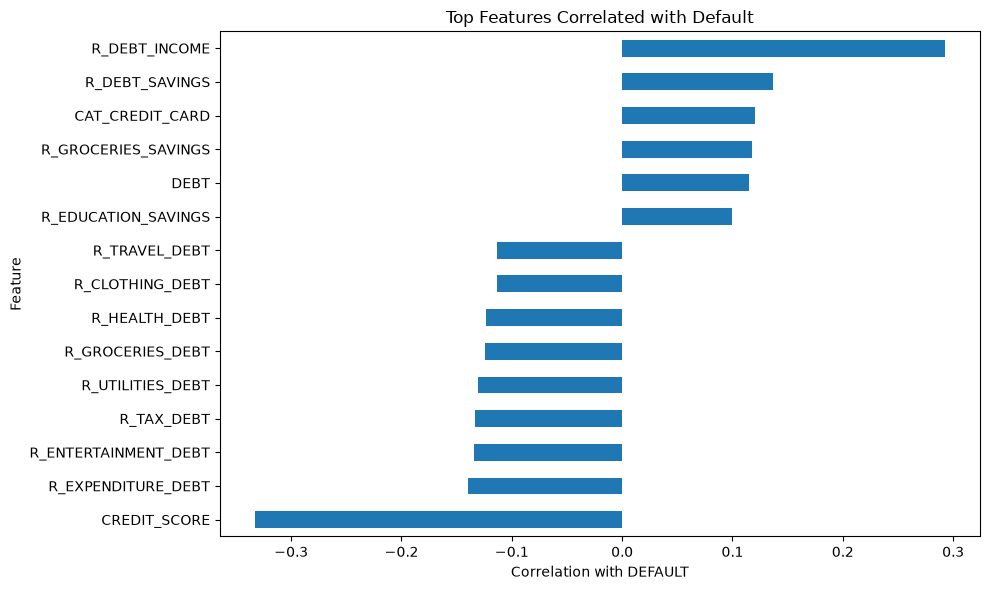

In [21]:
##Plot strongest relationships
top_features = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(10, 6))

target_correlations.loc[top_features].sort_values().plot(
    kind="barh"
)

plt.title("Top Features Correlated with Default")
plt.xlabel("Correlation with DEFAULT")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [22]:
## Single-feature predictive power
from sklearn.metrics import roc_auc_score

single_feature_auc = []

for column in numerical_features:

    if df[column].nunique() <= 1:
        continue

    auc = roc_auc_score(
        df[TARGET],
        df[column]
    )

    # AUC can be below 0.5 when larger values mean lower risk.
    # Convert it to predictive strength.
    adjusted_auc = max(
        auc,
        1 - auc
    )

    single_feature_auc.append({
        "feature": column,
        "raw_auc": auc,
        "predictive_auc": adjusted_auc
    })

single_feature_auc = (
    pd.DataFrame(single_feature_auc)
    .sort_values(
        "predictive_auc",
        ascending=False
    )
)

single_feature_auc.head(20)

,feature,raw_auc,predictive_auc
83,CREDIT_SCORE,0.3100,0.6900
4,R_DEBT_INCOME,0.6591,0.6591
59,R_TAX_DEBT,0.3412,0.6588
77,R_EXPENDITURE_DEBT,0.3501,0.6499
23,R_ENTERTAINMENT_DEBT,0.3651,0.6349
47,R_HEALTH_DEBT,0.3652,0.6348
11,R_CLOTHING_DEBT,0.3667,0.6333
71,R_UTILITIES_DEBT,0.3805,0.6195
5,R_DEBT_SAVINGS,0.6117,0.6117
41,R_GROCERIES_DEBT,0.4008,0.5992


In [23]:
credit_score_analysis = (
    df.groupby(TARGET)["CREDIT_SCORE"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
)

credit_score_analysis

,count,mean,median,min,max,std
DEFAULT,,,,,,
0,716,600.0084,606.5000,385,800,53.2996
1,284,553.1901,565.5000,300,691,73.7768


In [24]:
## Categorical feature analysis
gambling_analysis = (
    df.groupby("CAT_GAMBLING")[TARGET]
    .agg(
        customer_count="count",
        default_count="sum",
        default_rate="mean"
    )
)

gambling_analysis["default_rate"] *= 100

gambling_analysis.sort_values(
    "default_rate",
    ascending=False
)

,customer_count,default_count,default_rate
CAT_GAMBLING,,,
High,264,85,32.1970
Low,116,33,28.4483
No,620,166,26.7742


In [25]:
## Highly correlated feature analysis
numeric_feature_df = df[numerical_features]

corr_matrix = numeric_feature_df.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = []

for column in upper_triangle.columns:

    correlated_features = upper_triangle.index[
        upper_triangle[column] >= 0.95
    ].tolist()

    for feature in correlated_features:

        high_correlation_pairs.append({
            "feature_1": feature,
            "feature_2": column,
            "correlation": upper_triangle.loc[
                feature,
                column
            ]
        })

high_corr_df = (
    pd.DataFrame(high_correlation_pairs)
    .sort_values(
        "correlation",
        ascending=False
    )
)

high_corr_df

,feature_1,feature_2,correlation
4,T_HOUSING_12,T_HOUSING_6,1.0000
0,T_EDUCATION_12,T_EDUCATION_6,1.0000
7,T_UTILITIES_12,T_UTILITIES_6,1.0000
5,T_TAX_12,T_TAX_6,0.9957
2,T_GAMBLING_12,T_GAMBLING_6,0.9947
3,T_GROCERIES_12,T_GROCERIES_6,0.9916
9,INCOME,T_EXPENDITURE_12,0.9856
1,T_ENTERTAINMENT_12,T_ENTERTAINMENT_6,0.9827
11,T_EXPENDITURE_12,T_EXPENDITURE_6,0.9788
10,INCOME,T_EXPENDITURE_6,0.9594


In [26]:
# Check constant features
constant_features = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

constant_features

[]

In [27]:
# Check near-constant features
near_constant_features = []

for column in df.columns:

    frequency = (
        df[column]
        .value_counts(normalize=True, dropna=False)
        .iloc[0]
    )

    if frequency >= 0.95:

        near_constant_features.append({
            "feature": column,
            "dominant_percentage": frequency * 100
        })

pd.DataFrame(near_constant_features)


,feature,dominant_percentage
0,T_FINES_6,95.2000
1,CAT_SAVINGS_ACCOUNT,99.3000


In [28]:
high_cardinality_features = []

for column in df.select_dtypes(
    include=["object", "category"]
).columns:

    unique_ratio = (
        df[column].nunique() /
        len(df)
    )

    if unique_ratio > 0.90:

        high_cardinality_features.append({
            "feature": column,
            "unique_ratio": unique_ratio
        })

pd.DataFrame(high_cardinality_features)

,feature,unique_ratio
0,CUST_ID,1.0000


In [29]:
TARGET_COLUMN = "DEFAULT"

ID_COLUMNS = [
    "CUST_ID"
]

DROP_COLUMNS = [
    "CUST_ID"
]

CATEGORICAL_FEATURES = [
    "CAT_GAMBLING"
]

In [30]:
FEATURE_COLUMNS = [
    column
    for column in df.columns
    if column not in [
        TARGET_COLUMN,
        *ID_COLUMNS
    ]
]

len(FEATURE_COLUMNS)

85

In [31]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

TARGET = "DEFAULT"
ID_COLUMN = "CUST_ID"

# Separate target and predictors
X = df.drop(columns=[TARGET, ID_COLUMN], errors="ignore")
y = df[TARGET]

# Convert categorical variables into numeric dummy variables
X_encoded = pd.get_dummies(
    X,
    drop_first=False,
    dummy_na=True
)

# Replace infinite and missing values
X_encoded = (
    X_encoded
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Calculate mutual information with DEFAULT
mi_values = mutual_info_classif(
    X_encoded,
    y,
    discrete_features="auto",
    random_state=42
)

feature_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": mi_values
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
83,CREDIT_SCORE,0.0838
71,R_UTILITIES_DEBT,0.0579
5,R_DEBT_SAVINGS,0.0425
19,T_ENTERTAINMENT_6,0.0365
41,R_GROCERIES_DEBT,0.0358
11,R_CLOTHING_DEBT,0.0322
59,R_TAX_DEBT,0.0319
55,T_TAX_6,0.0311
17,R_EDUCATION_DEBT,0.0295
82,CAT_DEPENDENTS,0.0293


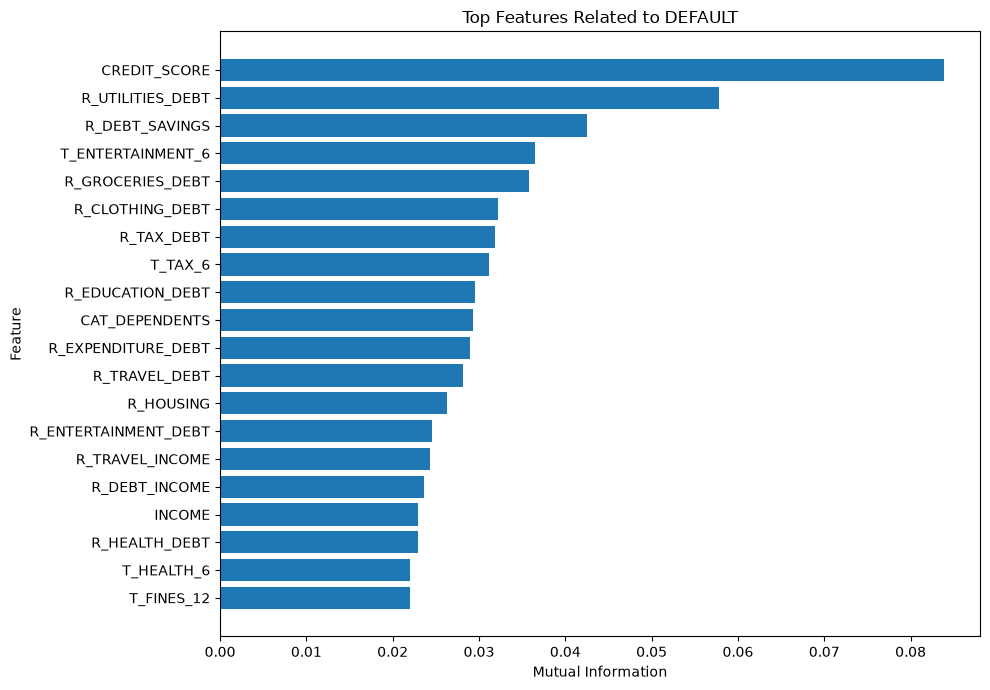

In [32]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Top Features Related to DEFAULT")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_encoded, y)

forest_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

forest_importance.head(20)

,feature,importance
83,CREDIT_SCORE,0.0428
4,R_DEBT_INCOME,0.0265
59,R_TAX_DEBT,0.0249
77,R_EXPENDITURE_DEBT,0.0218
11,R_CLOTHING_DEBT,0.0206
44,R_HEALTH,0.0202
38,R_GROCERIES,0.0195
14,R_EDUCATION,0.0190
5,R_DEBT_SAVINGS,0.0188
47,R_HEALTH_DEBT,0.0187
